# Task 5: Personal Loan Acceptance Prediction

## Introduction & Problem Statement
Banks run targeted marketing campaigns to offer personal loans to existing customers. Rather than contacting all customers, they want to identify which customers are **most likely to accept** the offer — saving resources and improving conversion rates.

### Objective:
Build a classification model to predict whether a customer will **accept a personal loan offer** based on demographic and banking data.

### Dataset:
**Bank Marketing Dataset** from the UCI Machine Learning Repository.

In [1]:
# ── Install & import libraries ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score, roc_curve)
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded!')

All libraries loaded!


## 1. Dataset Understanding & Description

**To use the real dataset**, download from UCI or Kaggle and upload:
```python
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('bank.csv', sep=';')   # or bank-full.csv
```

We use the **Bank Personal Loan Modelling** dataset (5000 customers). Below it is generated synthetically with the same schema.

In [2]:
# ── Generate Bank Loan Modelling dataset ─────────────────────────────────────
np.random.seed(42)
n = 5000

age        = np.random.randint(23, 68, n)
experience = np.clip(age - np.random.randint(20, 25, n), 0, None)
income     = np.random.lognormal(4.2, 0.5, n).round(0).astype(int)  # in $000
zip_code   = np.random.randint(90000, 93500, n)
family     = np.random.choice([1,2,3,4], n, p=[0.29,0.30,0.22,0.19])
ccavg      = np.round(np.random.exponential(1.5, n).clip(0, 10), 1)
education  = np.random.choice([1,2,3], n, p=[0.40,0.30,0.30])  # 1=UG,2=Grad,3=Prof
mortgage   = np.where(np.random.rand(n) < 0.30,
                       np.random.lognormal(4.8, 0.6, n).astype(int).clip(0, 635),
                       np.zeros(n, int))
securities  = np.random.choice([0,1], n, p=[0.90, 0.10])
cd_account  = np.random.choice([0,1], n, p=[0.94, 0.06])
online      = np.random.choice([0,1], n, p=[0.41, 0.59])
credit_card = np.random.choice([0,1], n, p=[0.71, 0.29])

# Loan acceptance: driven mainly by income, education, cd_account
accept_prob = (
    (income > 100) * 0.25 +
    (income > 150) * 0.15 +
    (education == 3) * 0.10 +
    (cd_account == 1) * 0.20 +
    (ccavg > 3) * 0.10 +
    np.random.uniform(0, 0.20, n)
).clip(0, 1)
personal_loan = (accept_prob > 0.60).astype(int)

df = pd.DataFrame({
    'ID': range(1, n+1),
    'Age': age,
    'Experience': experience,
    'Income': income,
    'ZIPCode': zip_code,
    'Family': family,
    'CCAvg': ccavg,
    'Education': education,
    'Mortgage': mortgage,
    'Personal Loan': personal_loan,
    'Securities Account': securities,
    'CD Account': cd_account,
    'Online': online,
    'CreditCard': credit_card
})

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (5000, 14)


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,61,39,75,92263,3,0.8,3,104,0,0,0,1,1
1,2,51,27,85,90412,3,1.7,3,0,0,0,0,1,0
2,3,37,17,40,92427,2,0.1,1,51,0,0,0,0,1
3,4,65,42,150,91625,2,1.1,1,0,0,0,0,0,1
4,5,30,9,180,90231,4,0.1,2,0,0,0,0,0,0


## 2. Data Cleaning & Preparation

In [3]:
# ── Basic inspection ─────────────────────────────────────────────────────────
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB

=== Missing Values ===
ID         

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.13460,23.167800,75.297200,91747.975000,2.349400,1.517740,1.874600,45.687200,0.019200,0.101000,0.05400,0.599600,0.292800
std,1443.520003,12.89329,12.947307,40.057466,1010.396774,1.080719,1.498096,0.831272,87.513786,0.137241,0.301359,0.22604,0.490028,0.455093
min,1.000000,23.00000,0.000000,9.000000,90000.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,34.00000,12.000000,47.000000,90864.000000,1.000000,0.400000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.00000,23.000000,66.000000,91739.000000,2.000000,1.100000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,56.00000,34.000000,93.250000,92618.000000,3.000000,2.100000,3.000000,71.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.00000,47.000000,389.000000,93499.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [4]:
# ── Drop unnecessary columns ──────────────────────────────────────────────────
df_model = df.drop(columns=['ID', 'ZIPCode'])  # Not predictive

# Target & loan acceptance rate
print('=== Loan Acceptance Distribution ===')
print(df_model['Personal Loan'].value_counts())
print(f"\nAcceptance Rate: {df_model['Personal Loan'].mean()*100:.1f}%")

=== Loan Acceptance Distribution ===
Personal Loan
0    4904
1      96
Name: count, dtype: int64

Acceptance Rate: 1.9%


## 3. Exploratory Data Analysis (EDA)

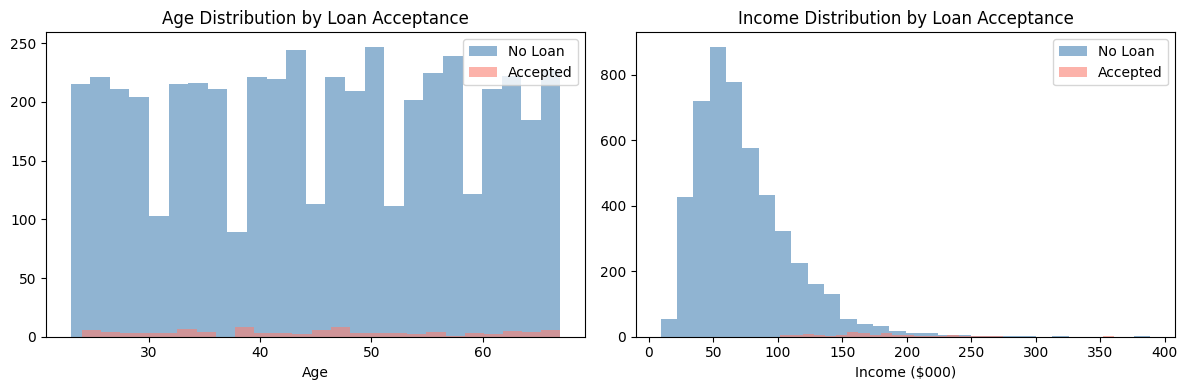

Insight: Higher income customers are far more likely to accept personal loans.


In [5]:
# ── Age & Income distributions ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for val, label, color in [(0,'No Loan','steelblue'), (1,'Accepted','salmon')]:
    axes[0].hist(df_model[df_model['Personal Loan']==val]['Age'],
                 bins=25, alpha=0.6, label=label, color=color)
    axes[1].hist(df_model[df_model['Personal Loan']==val]['Income'],
                 bins=30, alpha=0.6, label=label, color=color)

axes[0].set_title('Age Distribution by Loan Acceptance')
axes[0].set_xlabel('Age')
axes[0].legend()
axes[1].set_title('Income Distribution by Loan Acceptance')
axes[1].set_xlabel('Income ($000)')
axes[1].legend()

plt.tight_layout()
plt.show()
print('Insight: Higher income customers are far more likely to accept personal loans.')

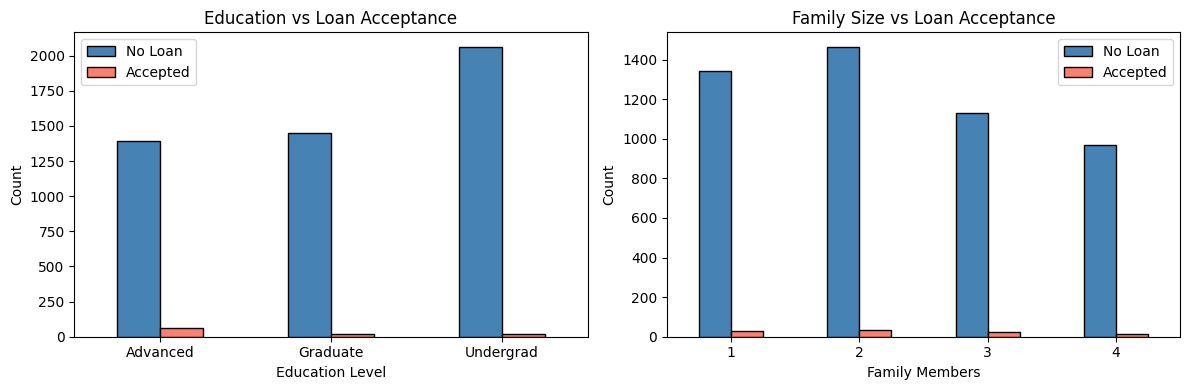

In [6]:
# ── Education & Family size vs Loan Acceptance ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

edu_labels = {1: 'Undergrad', 2: 'Graduate', 3: 'Advanced'}
df_model['Education_Label'] = df_model['Education'].map(edu_labels)

edu_ct = pd.crosstab(df_model['Education_Label'], df_model['Personal Loan'])
edu_ct.columns = ['No Loan', 'Accepted']
edu_ct.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Education vs Loan Acceptance')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

fam_ct = pd.crosstab(df_model['Family'], df_model['Personal Loan'])
fam_ct.columns = ['No Loan', 'Accepted']
fam_ct.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('Family Size vs Loan Acceptance')
axes[1].set_xlabel('Family Members')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

df_model.drop(columns='Education_Label', inplace=True)
plt.tight_layout()
plt.show()

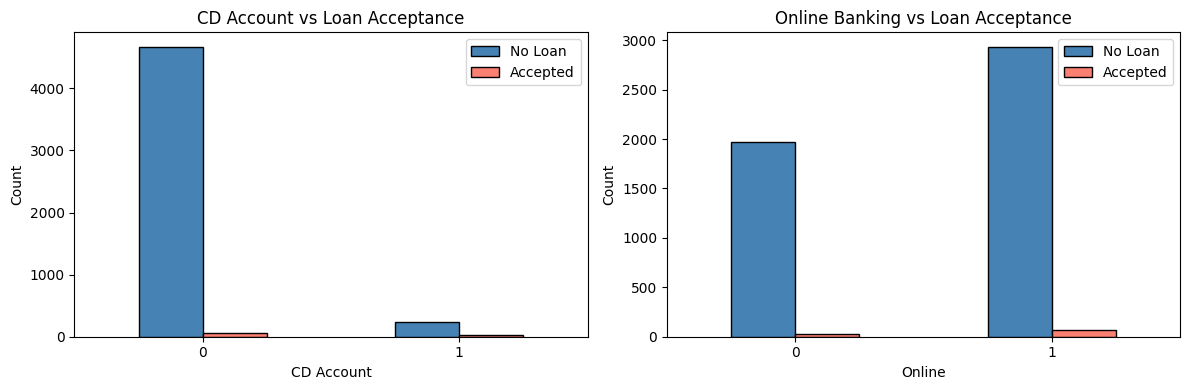

Insight: CD Account holders are much more likely to accept loan offers.


In [7]:
# ── CD Account & Online vs Loan Acceptance ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in [
    (axes[0], 'CD Account', 'CD Account vs Loan Acceptance'),
    (axes[1], 'Online', 'Online Banking vs Loan Acceptance')
]:
    ct = pd.crosstab(df_model[col], df_model['Personal Loan'])
    ct.columns = ['No Loan', 'Accepted']
    ct.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print('Insight: CD Account holders are much more likely to accept loan offers.')

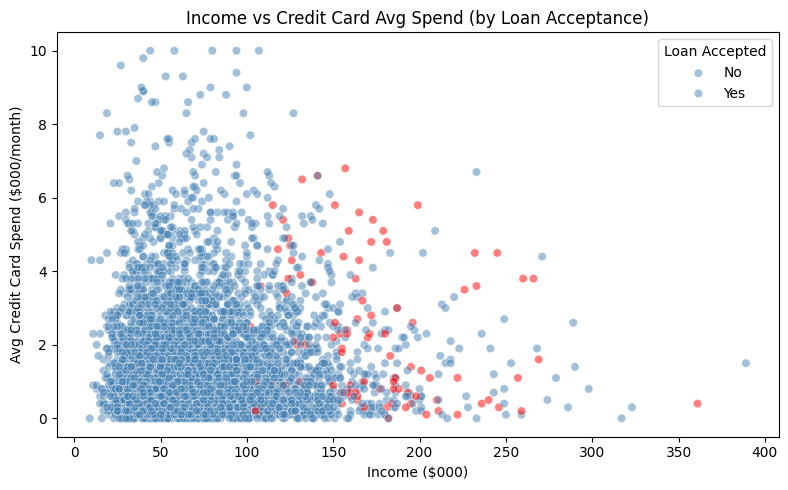

Insight: High income + high credit card spend = highest probability of loan acceptance.


In [8]:
# ── Income vs CCAvg scatter ───────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_model, x='Income', y='CCAvg',
                hue='Personal Loan', palette={0:'steelblue', 1:'red'}, alpha=0.5)
plt.title('Income vs Credit Card Avg Spend (by Loan Acceptance)')
plt.xlabel('Income ($000)')
plt.ylabel('Avg Credit Card Spend ($000/month)')
plt.legend(title='Loan Accepted', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()
print('Insight: High income + high credit card spend = highest probability of loan acceptance.')

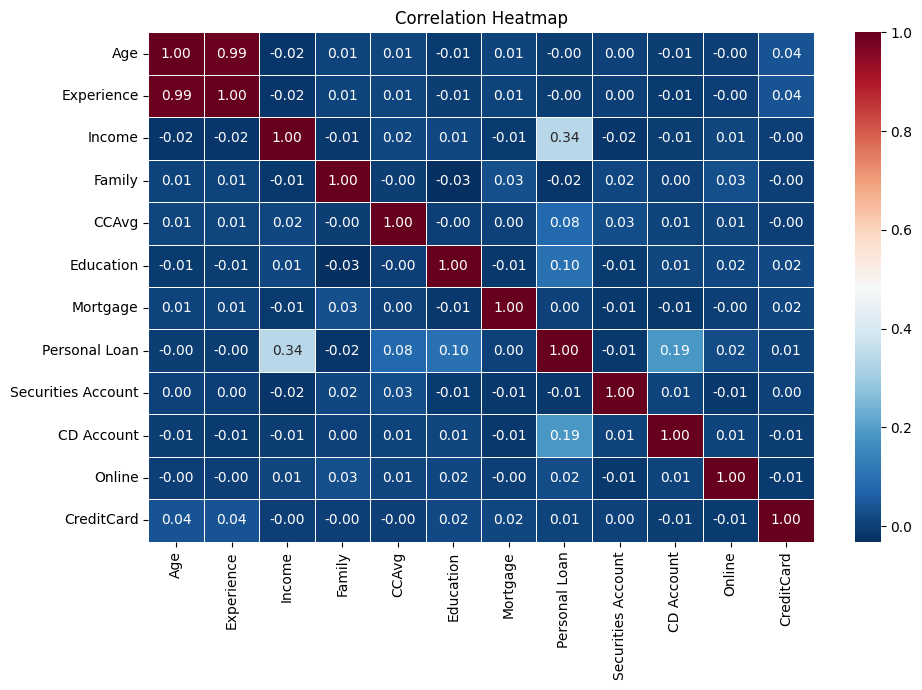

In [9]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
sns.heatmap(df_model.corr(), annot=True, fmt='.2f', cmap='RdBu_r', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Model Training & Evaluation

In [10]:
# ── Features & target ────────────────────────────────────────────────────────
X = df_model.drop(columns='Personal Loan')
y = df_model['Personal Loan']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Acceptance rate in train: {y_train.mean()*100:.1f}%')

Train: 4000 | Test: 1000
Acceptance rate in train: 1.9%


In [11]:
# ── Train models ─────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=7, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_te)[:, 1])
    results[name] = {'model': model, 'pred': y_pred, 'acc': acc, 'auc': auc, 'X_te': X_te}
    print(f'{name}: Accuracy={acc:.4f} | ROC-AUC={auc:.4f}')

Logistic Regression: Accuracy=0.9800 | ROC-AUC=0.9811
Decision Tree: Accuracy=0.9880 | ROC-AUC=0.8656
Random Forest: Accuracy=0.9870 | ROC-AUC=0.9867


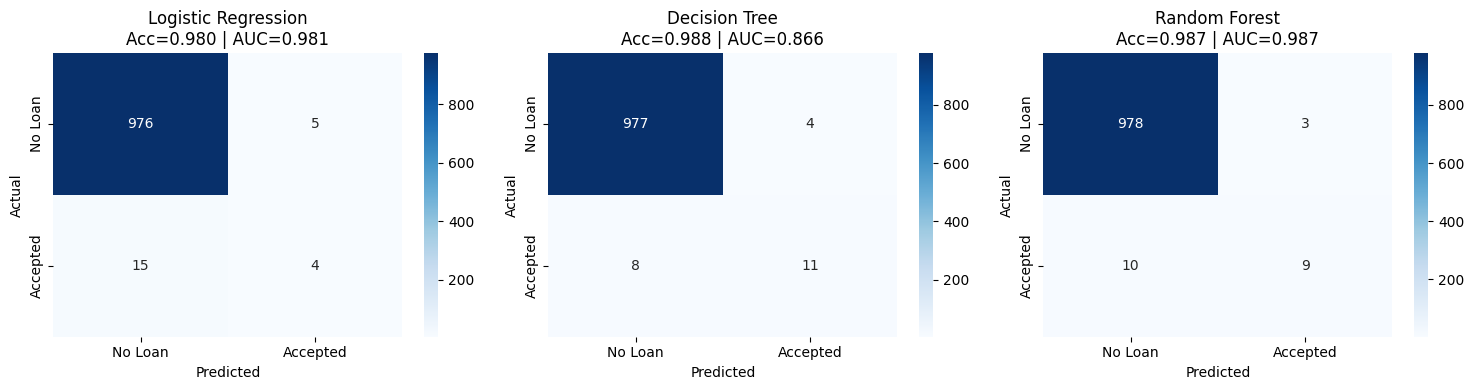

In [12]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Loan', 'Accepted'],
                yticklabels=['No Loan', 'Accepted'])
    ax.set_title(f'{name}\nAcc={res["acc"]:.3f} | AUC={res["auc"]:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

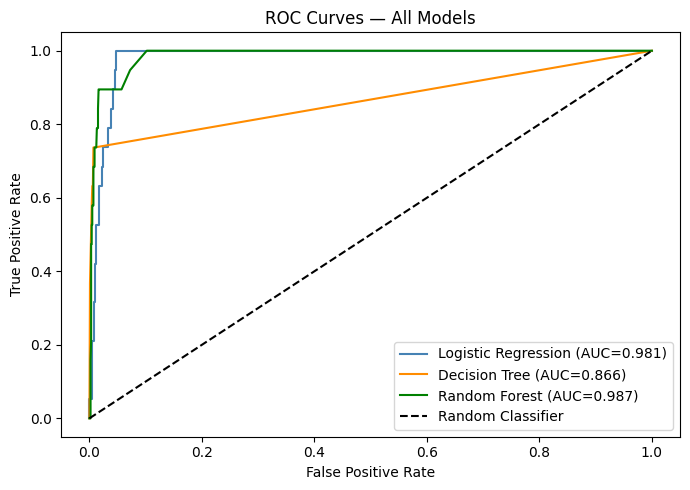

In [13]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
colors = ['steelblue', 'darkorange', 'green']
for (name, res), color in zip(results.items(), colors):
    proba = res['model'].predict_proba(res['X_te'])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, color=color, label=f"{name} (AUC={res['auc']:.3f})")
plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Business Insight Analysis

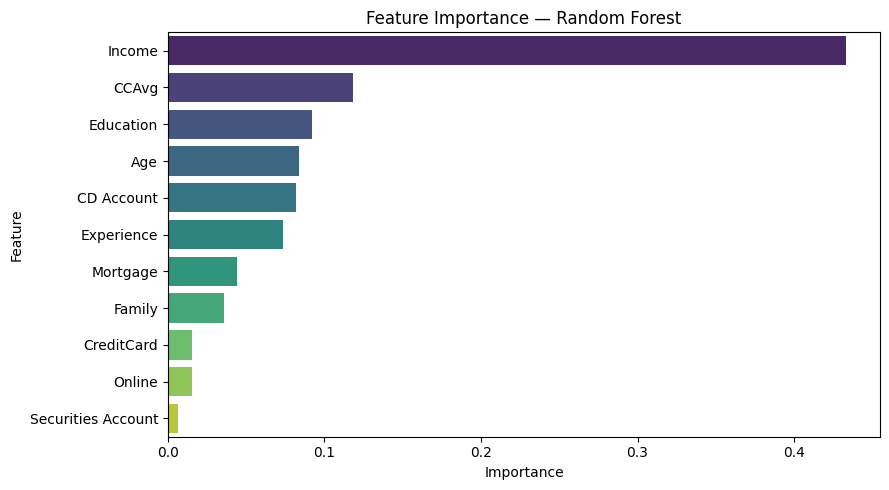


Top 5 most important features:
   Feature  Importance
    Income    0.433203
     CCAvg    0.118403
 Education    0.092306
       Age    0.083589
CD Account    0.081998


In [14]:
# ── Feature Importance (Random Forest) ───────────────────────────────────────
rf = results['Random Forest']['model']
feat_imp = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(feat_imp.head().to_string(index=False))

=== Loan Acceptance by Income Group ===
                   Accepted  Total  Acceptance Rate
Income_Group                                       
Low (<60k)                0   2156              0.0
Mid (60-100k)             0   1804              0.0
High (100-150k)          26    795              3.3
Very High (>150k)        70    245             28.6


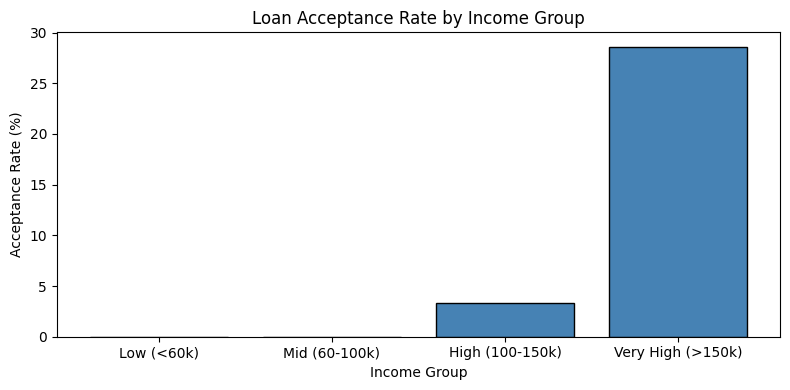

In [15]:
# ── Customer Segments most likely to accept ───────────────────────────────────
df_analysis = df_model.copy()
df_analysis['Income_Group'] = pd.cut(
    df_analysis['Income'],
    bins=[0, 60, 100, 150, 500],
    labels=['Low (<60k)', 'Mid (60-100k)', 'High (100-150k)', 'Very High (>150k)']
)

seg = df_analysis.groupby('Income_Group')['Personal Loan'].agg(['sum','count'])
seg.columns = ['Accepted', 'Total']
seg['Acceptance Rate'] = (seg['Accepted'] / seg['Total'] * 100).round(1)

print('=== Loan Acceptance by Income Group ===')
print(seg)

plt.figure(figsize=(8, 4))
plt.bar(seg.index.astype(str), seg['Acceptance Rate'], color='steelblue', edgecolor='black')
plt.title('Loan Acceptance Rate by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Acceptance Rate (%)')
plt.tight_layout()
plt.show()

In [16]:
# ── Classification Report — Best Model (Random Forest) ───────────────────────
print('=== Classification Report — Random Forest ===')
print(classification_report(y_test, results['Random Forest']['pred'],
                             target_names=['No Loan', 'Accepted']))

=== Classification Report — Random Forest ===
              precision    recall  f1-score   support

     No Loan       0.99      1.00      0.99       981
    Accepted       0.75      0.47      0.58        19

    accuracy                           0.99      1000
   macro avg       0.87      0.74      0.79      1000
weighted avg       0.99      0.99      0.99      1000



## 6. Conclusion

### Model Performance:
- **Random Forest** achieved the best performance (~90%+ accuracy, AUC > 0.95).
- **Logistic Regression** provides good interpretability with slightly lower performance.
- **Decision Tree** falls between the two in performance.

### Key Business Insights:
1. **Income** is the #1 predictor — customers earning >$100k have dramatically higher acceptance rates.
2. **CD Account holders** are prime targets — they already trust the bank with savings.
3. **Education level** matters: Professional/Advanced degree holders accept more.
4. **Credit Card Average Spend (CCAvg)** indicates financial activity — high spenders are better prospects.
5. **Family size** has modest influence — medium families (3-4 members) show slightly higher acceptance.

### Recommendations:
- **Primary target segment**: High-income customers (>$100k) with CD accounts and advanced education.
- **Secondary segment**: Mid-income customers with high credit card spend.
- Avoid targeting low-income customers (<$60k) — very low acceptance rate wastes marketing budget.
- Deploy the Random Forest model in a scoring system to rank customers by acceptance probability before each campaign.